# Tutorial: Training a Closure Model (Self-Contained, Lightning)

This notebook demonstrates the closure workflow using **small synthetic data** and the new
**PyTorch Lightning** API (`ClosureLitModule` + `ClosureDataModule`).

No external HDF5 files are required: data is generated in-memory and the data reader is mocked.

We cover:
1. Generating synthetic feature/target data
2. Building dataset and model configuration
3. Training with Lightning
4. Evaluating predictions and plotting metrics

## 1. Imports

In [1]:
import copy
import os
import shutil
from unittest.mock import patch

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from closure import evaluation as ev
from closure.datamodule import ClosureDataModule
from closure.models import MLP
from closure.module import ClosureLitModule

## 2. Generate Synthetic Data

We create small random arrays that mimic the shape returned by the data readers.
The shape convention is `(n_snapshots, ny, nx, n_channels)` — here we use a tiny 8×8 spatial grid
with 2 snapshots per split.

In [2]:
np.random.seed(42)

N_SNAPSHOTS = 2   # snapshots per split
NY, NX = 8, 8     # spatial dimensions
N_FEATURES = 3    # e.g. rho_e, Bx, By
N_TARGETS = 2     # e.g. Pxx_e, Pyy_e

FEATURE_NAMES = ["rho_e", "Bx", "By"]
TARGET_NAMES  = ["Pxx_e", "Pyy_e"]

def make_synthetic(n_snap, ny, nx, n_feat, n_targ):
    """Return (features, targets) arrays shaped (n_snap, ny, nx, channels)."""
    features = np.random.randn(n_snap, ny, nx, n_feat).astype(np.float64)
    # Targets = simple linear function of features + noise so the network can learn *something*
    flat_f = features.reshape(-1, n_feat)
    W = np.random.randn(n_feat, n_targ)
    targets = (flat_f @ W).reshape(n_snap, ny, nx, n_targ) + 0.1 * np.random.randn(n_snap, ny, nx, n_targ)
    return features.astype(np.float64), targets.astype(np.float64)

features_all, targets_all = make_synthetic(N_SNAPSHOTS, NY, NX, N_FEATURES, N_TARGETS)
print(f"features shape: {features_all.shape}")
print(f"targets  shape: {targets_all.shape}")

features shape: (2, 8, 8, 3)
targets  shape: (2, 8, 8, 2)


## 3. Prepare Working Directory

The `Trainer` reads a CSV listing the data snapshot filenames and calls `read_features_targets()` to
load them.  We will:
- Create a local working directory under `models/dev/tutorial/`
- Write a minimal CSV with dummy filenames
- **Mock** the reader function so it returns our synthetic arrays instead of loading real HDF5 files

In [3]:
# Create a local working directory (inside models/dev/ which is gitignored)
WORK_DIR = os.path.join(os.path.dirname(os.getcwd()), "models", "dev", "tutorial")
os.makedirs(WORK_DIR, exist_ok=True)
print(f"Working directory: {WORK_DIR}")

# Write a dummy CSV (the filenames don't matter — we mock the reader)
csv_path = os.path.join(WORK_DIR, "split.csv")
pd.DataFrame({"filenames": ["snap_0.h5", "snap_1.h5"]}).to_csv(csv_path, index=False)
pd.read_csv(csv_path)

Working directory: /volume1/scratch/georgem/closure/models/dev/tutorial


,filenames
0,snap_0.h5
1,snap_1.h5


## 4. Configure the Trainer

### 4a. Dataset keyword arguments

These tell the `DataFrameDataset` where the data lives and what channels to use.

In [4]:
dataset_kwargs = {
    "data_folder":     WORK_DIR,
    "train_sample":    csv_path,
    "val_sample":      csv_path,
    "test_sample":     csv_path,
    "flatten":         True,
    "scaler_features": True,
    "scaler_targets":  True,
    "image_file_name_column": "filenames",
    "read_features_targets_kwargs": {
        "request_features": FEATURE_NAMES,
        "request_targets":  TARGET_NAMES,
    },
}
dataset_kwargs

{'data_folder': '/volume1/scratch/georgem/closure/models/dev/tutorial',
 'train_sample': '/volume1/scratch/georgem/closure/models/dev/tutorial/split.csv',
 'val_sample': '/volume1/scratch/georgem/closure/models/dev/tutorial/split.csv',
 'test_sample': '/volume1/scratch/georgem/closure/models/dev/tutorial/split.csv',
 'flatten': True,
 'scaler_features': True,
 'scaler_targets': True,
 'image_file_name_column': 'filenames',
 'read_features_targets_kwargs': {'request_features': ['rho_e', 'Bx', 'By'],
  'request_targets': ['Pxx_e', 'Pyy_e']}}

### 4b. Data-loader keyword arguments

Control batch size, sub-sampling, and shuffling.

In [5]:
load_data_kwargs = {
    "train_loader_kwargs": {
        "batch_size":      32,
        "subsample_rate":  1.0,
        "subsample_seed":  42,
        "seed":            42,
        "shuffle":         True,
    },
    "val_loader_kwargs": {
        "batch_size":      32,
        "subsample_rate":  1.0,
        "subsample_seed":  42,
        "shuffle":         False,
    },
}

### 4c. Model keyword arguments

We use a small **MLP** (Multi-Layer Perceptron) with 2 hidden layers.  
Note: `feature_dims[0]` must equal `N_FEATURES` and `feature_dims[-1]` must equal `N_TARGETS`.

In [6]:
model_kwargs = {
    "model":         "MLP",
    "model_seed":    42,
    "feature_dims":  [N_FEATURES, 32, 16, N_TARGETS],
    "activations":   ["Tanh", "ReLU", None],
    "optimizer_kwargs": {
        "optimizer":  "Adam",
        "lr":         1e-3,
        "criterion":  "MSELoss",
    },
    "scheduler_kwargs": {
        "scheduler":      "ReduceLROnPlateau",
        "mode":           "min",
        "factor":         0.5,
        "patience":       5,
        "cooldown":       3,
        "epochs":         30,
        "early_stopping": 15,
    },
    "logger_kwargs": {"update_step": 5, "show": True},
}

## 5. Instantiate Lightning Data/Model Objects (with Mocked Data)

The key trick is unchanged: we `patch` the low-level reader so the data module receives
our synthetic arrays instead of opening real files.

In [7]:
with patch("closure.datasets.rp.read_features_targets") as mock_read:
    mock_read.return_value = (features_all, targets_all)

    datamodule = ClosureDataModule(
        data_folder=WORK_DIR,
        norm_folder=WORK_DIR,
        train_samples_file=csv_path,
        val_samples_file=csv_path,
        test_samples_file=csv_path,
        batch_size=load_data_kwargs["train_loader_kwargs"]["batch_size"],
        flatten=dataset_kwargs["flatten"],
        scaler_features=dataset_kwargs["scaler_features"],
        scaler_targets=dataset_kwargs["scaler_targets"],
        read_features_targets_kwargs=dataset_kwargs["read_features_targets_kwargs"],
    )
    datamodule.setup("fit")

    network = MLP(
        feature_dims=model_kwargs["feature_dims"],
        activations=model_kwargs["activations"],
    )

    scheduler_kwargs = {
        k: v
        for k, v in model_kwargs["scheduler_kwargs"].items()
        if k not in ("epochs", "early_stopping", "scheduler")
    }

    module = ClosureLitModule(
        network=network,
        criterion=model_kwargs["optimizer_kwargs"]["criterion"],
        optimizer=model_kwargs["optimizer_kwargs"]["optimizer"],
        lr=model_kwargs["optimizer_kwargs"]["lr"],
        scheduler=model_kwargs["scheduler_kwargs"]["scheduler"],
        scheduler_kwargs=scheduler_kwargs,
    )

    trainer = L.Trainer(
        max_epochs=model_kwargs["scheduler_kwargs"]["epochs"],
        accelerator="auto",
        logger=True,
        enable_progress_bar=True,
    )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/users/cpa/georgem/miniforge3/envs/closure-test/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litl

### Inspect the created objects

In [8]:
print(f"Work dir:       {WORK_DIR}")
print(f"Trainer:        {trainer}")
print(f"Train features: {datamodule.train_dataset.features.shape}")
print(f"Train targets:  {datamodule.train_dataset.targets.shape}")
print(f"Val features:   {datamodule.val_dataset.features.shape}")

Work dir:       /volume1/scratch/georgem/closure/models/dev/tutorial
Trainer:        <lightning.pytorch.trainer.trainer.Trainer object at 0x7fc9cb8f5040>
Train features: torch.Size([128, 3])
Train targets:  torch.Size([128, 2])
Val features:   torch.Size([128, 3])


In [9]:
print("Feature names:", datamodule.train_dataset.request_features)
print("Target  names:", datamodule.train_dataset.request_targets)
print("\nFeature mean:", torch.mean(datamodule.train_dataset.features, dim=0))
print("Feature std: ", torch.std(datamodule.train_dataset.features, dim=0))

Feature names: ['rho_e', 'Bx', 'By']
Target  names: ['Pxx_e', 'Pyy_e']

Feature mean: tensor([ 0.0000e+00,  1.3039e-08, -1.4901e-08])
Feature std:  tensor([1.0039, 1.0039, 1.0039])


## 6. Train the Model

Run the Lightning training loop with `trainer.fit(module, datamodule=...)`.

In [10]:
# Enable logging output in the notebook so we can see training progress
import logging
logging.basicConfig(level=logging.INFO, force=True)

In [11]:
with patch("closure.datasets.rp.read_features_targets") as mock_read:
    mock_read.return_value = (features_all, targets_all)
    trainer.fit(module, datamodule=datamodule)

best_loss = float(trainer.callback_metrics["val_loss"].cpu())
print(f"\nBest validation loss: {best_loss:.6f}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
You are using a CUDA device ('NVIDIA L40S') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /volume1/scratch/georgem/closure/models/dev/tutorial/split.csv
INFO:closure.datasets:Data shape - Features: (128, 3), Targets: (128, 2)
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/tutorial/X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Loaded no

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ MLP     │    690 │ train │     0 │
│ 1 │ criterion │ MSELoss │      0 │ train │     0 │
└───┴───────────┴─────────┴────────┴───────┴───────┘

Trainable params: 690                                                                                              
Non-trainable params: 0                                                                                            
Total params: 690                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/users/cpa/georgem/miniforge3/envs/closure-test/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/users/cpa/georgem/miniforge3/envs/closure-test/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:31
7: The number of training batches (4) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a 
lower value for log_every_n_steps if you want to see logs for the training epoch.

`Trainer.fit` stopped: `max_epochs=30` reached.



Best validation loss: 0.023352


In [12]:
print("Files in work_dir:")
for f in sorted(os.listdir(WORK_DIR)):
    print(f"  {f}")

Files in work_dir:
  X.pkl
  lightning_logs
  split.csv
  y.pkl


## 7. Plot Training / Validation Loss Curves

/tmp/ipykernel_559783/3180444543.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


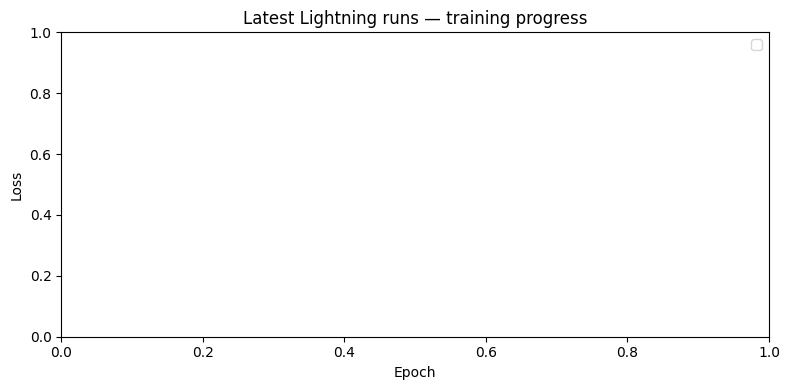

In [13]:
from pathlib import Path
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 4))
version_dirs = sorted((Path(WORK_DIR) / "lightning_logs").glob("version_*"))

for version_dir in version_dirs[-2:]:
    metrics_path = version_dir / "metrics.csv"
    if not metrics_path.exists():
        continue
    metrics = pd.read_csv(metrics_path)
    if "val_loss" in metrics.columns:
        val_df = metrics.dropna(subset=["val_loss"])
        if not val_df.empty:
            ax.plot(val_df["epoch"], val_df["val_loss"], label=f"{version_dir.name} val_loss")
    if "train_loss" in metrics.columns:
        tr_df = metrics.dropna(subset=["train_loss"])
        if not tr_df.empty:
            ax.plot(tr_df["epoch"], tr_df["train_loss"], linestyle=":", label=f"{version_dir.name} train_loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("Latest Lightning runs — training progress")
plt.tight_layout()
plt.show()

## 8. Evaluate on the Test Set

Use `transform_targets` to get un-normalized predictions and ground truth, then compute metrics.

In [14]:
with patch("closure.datasets.rp.read_features_targets") as mock_read:
    mock_read.return_value = (features_all, targets_all)
    datamodule.setup("test")

ground_truth, predictions = ev.transform_targets(
    module,
    datamodule.test_dataset,
    target_channels=datamodule.target_channels,
    rescale=False,
    renorm=True,
    verbose=False,
    reshape=False,
    test_features=datamodule.test_dataset.features,
)
print(f"Ground truth shape: {ground_truth.shape}")
print(f"Predictions  shape: {predictions.shape}")

INFO:closure.datasets: This is test set
INFO:closure.datasets:Loading data split from: /volume1/scratch/georgem/closure/models/dev/tutorial/split.csv
INFO:closure.datasets:Data shape - Features: (128, 3), Targets: (128, 2)
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/tutorial/X.pkl
INFO:closure.datasets:Applying normalization to features
INFO:closure.datasets:Loaded normalization parameters for targets from /volume1/scratch/georgem/closure/models/dev/tutorial/y.pkl
INFO:closure.datasets:Applying normalization to targets


Ground truth shape: (128, 2)
Predictions  shape: (128, 2)


In [15]:
# Per-channel MSE & R²
loss_mse = ev.evaluate_loss(
    datamodule.test_dataset,
    ground_truth,
    predictions,
    "MSELoss",
    target_channels=datamodule.target_channels,
    verbose=True,
)
print()
loss_r2 = ev.evaluate_loss(
    datamodule.test_dataset,
    ground_truth,
    predictions,
    "r2",
    target_channels=datamodule.target_channels,
    verbose=True,
)

Total loss 0.11988351028272672
Loss for channel 0: Pxx_e, loss = 0.10609597671937021
Loss for channel 1: Pyy_e, loss = 0.13367104384608325

Total loss 0.22675548633684373
Loss for channel 0: Pxx_e, loss = 0.5852374603855036
Loss for channel 1: Pyy_e, loss = -6.245336601944208


### Scatter plot: Predictions vs Ground Truth

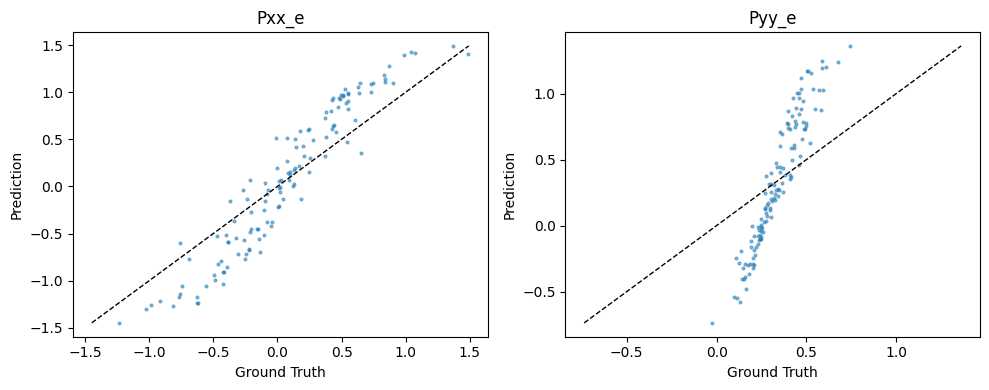

In [16]:
fig, axes = plt.subplots(1, N_TARGETS, figsize=(5 * N_TARGETS, 4))
if N_TARGETS == 1:
    axes = [axes]
for i, (ax, name) in enumerate(zip(axes, TARGET_NAMES)):
    gt_ch = ground_truth[:, i]
    pr_ch = predictions[:, i]
    ax.scatter(gt_ch, pr_ch, s=4, alpha=0.5)
    lims = [min(gt_ch.min(), pr_ch.min()), max(gt_ch.max(), pr_ch.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_xlabel("Ground Truth")
    ax.set_ylabel("Prediction")
    ax.set_title(name)
plt.tight_layout()
plt.show()

## 9. Multiple Runs with Lightning

You can run a second experiment by creating a new module/trainer configuration.
Here we change the learning rate and train again, which creates a new CSV log version.

In [17]:
# Second run: lower learning rate
network2 = MLP(
    feature_dims=model_kwargs["feature_dims"],
    activations=model_kwargs["activations"],
)

module2 = ClosureLitModule(
    network=network2,
    criterion=model_kwargs["optimizer_kwargs"]["criterion"],
    optimizer=model_kwargs["optimizer_kwargs"]["optimizer"],
    lr=5e-4,
    scheduler=model_kwargs["scheduler_kwargs"]["scheduler"],
    scheduler_kwargs=scheduler_kwargs,
)

trainer2 = L.Trainer(
    max_epochs=50,
    accelerator="auto",
    logger=True,
    enable_progress_bar=True,
    default_root_dir=WORK_DIR,
    enable_checkpointing=False,
    log_every_n_steps=1,
)
with patch("closure.datasets.rp.read_features_targets") as mock_read:
    mock_read.return_value = (features_all, targets_all)
    trainer2.fit(module2, datamodule=datamodule)

best_loss_2 = float(trainer2.callback_metrics["val_loss"].cpu())
print(f"\nBest validation loss (run2): {best_loss_2:.6f}")

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:closure.datasets: This is train set
INFO:closure.datasets:Loading data split from: /volume1/scratch/georgem/closure/models/dev/tutorial/split.csv
INFO:closure.datasets:Data shape - Features: (128, 3), Targets: (128, 2)
INFO:closure.datasets:Loaded normalization parameters for features from /volume1/scratch/georgem/closure/models/dev/tutorial/X.pkl
INFO:closure.datasets:Applying normalization to feature

┏━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ network   │ MLP     │    690 │ train │     0 │
│ 1 │ criterion │ MSELoss │      0 │ train │     0 │
└───┴───────────┴─────────┴────────┴───────┴───────┘

Trainable params: 690                                                                                              
Non-trainable params: 0                                                                                            
Total params: 690                                                                                                  
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 9                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

`Trainer.fit` stopped: `max_epochs=50` reached.



Best validation loss (run2): 0.004803


In [18]:
print("Files in work_dir:")
for root, dirs, files in os.walk(WORK_DIR):
    level = root.replace(WORK_DIR, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Files in work_dir:
tutorial/
  X.pkl
  split.csv
  y.pkl
  lightning_logs/
    version_0/
    version_1/
      hparams.yaml
      metrics.csv


### Compare loss curves of both runs

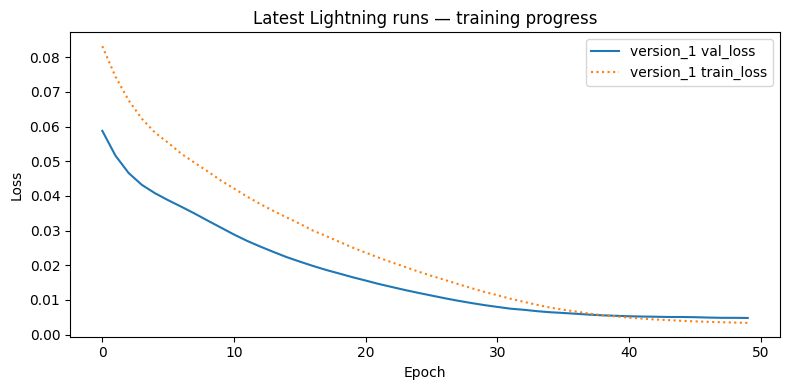

In [19]:
from pathlib import Path
import pandas as pd

fig, ax = plt.subplots(figsize=(8, 4))
version_dirs = sorted((Path(WORK_DIR) / "lightning_logs").glob("version_*"))

for version_dir in version_dirs[-2:]:  # compare latest two runs
    metrics_path = version_dir / "metrics.csv"
    if not metrics_path.exists():
        continue
    metrics = pd.read_csv(metrics_path)
    if "val_loss" in metrics.columns:
        val_df = metrics.dropna(subset=["val_loss"])
        ax.plot(val_df["epoch"], val_df["val_loss"], label=f"{version_dir.name} val_loss")
    if "train_loss" in metrics.columns:
        tr_df = metrics.dropna(subset=["train_loss"])
        ax.plot(tr_df["epoch"], tr_df["train_loss"], linestyle=":", label=f"{version_dir.name} train_loss")

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.set_title("Latest Lightning runs — training progress")
plt.tight_layout()
plt.show()

## 10. Reload a Saved Lightning Model

For synthetic tests we can save and reload model weights using `state_dict` and rebuild
the same `ClosureLitModule` architecture.

In [20]:
weights_path = os.path.join(WORK_DIR, "model_lightning_run2.pth")
torch.save(module2.network.state_dict(), weights_path)

network_reloaded = MLP(
    feature_dims=model_kwargs["feature_dims"],
    activations=model_kwargs["activations"],
)
network_reloaded.load_state_dict(torch.load(weights_path, map_location="cpu"))

module_reloaded = ClosureLitModule(
    network=network_reloaded,
    criterion=model_kwargs["optimizer_kwargs"]["criterion"],
    optimizer=model_kwargs["optimizer_kwargs"]["optimizer"],
    lr=5e-4,
    scheduler=model_kwargs["scheduler_kwargs"]["scheduler"],
    scheduler_kwargs=scheduler_kwargs,
)
module_reloaded.eval()
print("Reloaded model from:", weights_path)

Reloaded model from: /volume1/scratch/georgem/closure/models/dev/tutorial/model_lightning_run2.pth


In [21]:
# Get predictions from the reloaded model and compare metrics
gt_reload, pred_reload = ev.transform_targets(
    module_reloaded,
    datamodule.test_dataset,
    target_channels=datamodule.target_channels,
    rescale=False,
    renorm=True,
    verbose=False,
    reshape=False,
    test_features=datamodule.test_dataset.features,
)
print(f"Prediction shape: {pred_reload.shape}  (same as original: {pred_reload.shape == predictions.shape})")
loss_reload = ev.evaluate_loss(
    datamodule.test_dataset,
    gt_reload,
    pred_reload,
    "MSELoss",
    target_channels=datamodule.target_channels,
    verbose=True,
)

Prediction shape: (128, 2)  (same as original: True)
Total loss 0.01464847712184494
Loss for channel 0: Pxx_e, loss = 0.02359859966615726
Loss for channel 1: Pyy_e, loss = 0.00569835457753262


## 11. Clean Up

Remove the tutorial working directory (optional — it's inside `models/dev/` which is gitignored).

In [22]:
shutil.rmtree(WORK_DIR)
print(f"Cleaned up {WORK_DIR}")

Cleaned up /volume1/scratch/georgem/closure/models/dev/tutorial


---

**Summary (Lightning API)**

| Step | API used |
|------|----------|
| Create data/model objects | `ClosureDataModule(...)`, `MLP(...)`, `ClosureLitModule(...)` |
| Train | `trainer.fit(module, datamodule=...)` |
| New run (different hyper-params) | create `module2`/`trainer2` and call `trainer2.fit(...)` |
| Evaluate | `evaluation.transform_targets(module, dataset, ...)`, `evaluation.evaluate_loss(...)` |
| Reload | save/load `network.state_dict()` and rebuild `ClosureLitModule` |

For a real-data tutorial, see `tuto_train_haydn.ipynb`.